In [6]:
import torch
from torch import nn

import math
from matplotlib import pyplot as plt

from func.load_mnist import load_mnist
from func.validate_model import validate_model

from Model_QuantizedAE import QuantizedAE

In [7]:
train_dl, validate_dl = load_mnist()

In [8]:
# The layout contains rows:
#   row 0 — original images   (n_samples columns)
#   row 1 — predicted images (n_samples columns)

def plot_result_image_table(
    model,
    model_name,
    dataset_loader: torch.utils.data.DataLoader,
    n_samples: int = 20,
):
    pltimg = lambda x: x.squeeze().detach().cpu().numpy()

    # Collect samples (image tensor + integer label)
    samples = [dataset_loader.dataset[i] for i in range(n_samples)]
    images = [s[0] for s in samples]
    labels = [s[1] for s in samples]

    fig, axes = plt.subplots(2, n_samples, figsize=(2 * n_samples, 5))
    fig.suptitle(
        f"{model_name}\nOriginal vs Preprocessed input",
        fontsize=13,
        fontweight="bold",
    )

    # Row labels on the leftmost column
    axes[0, 0].set_ylabel("Original", fontsize=10, fontweight="bold")
    axes[1, 0].set_ylabel("Preprocessed", fontsize=10, fontweight="bold")

    model.eval()
    param = next(model.parameters(), None)
    device = param.device if param is not None else torch.device('cpu')
    with torch.no_grad():
        for i, (img, label) in enumerate(zip(images, labels)):
            # ── original ────────────────────────────────────────────────
            orig_np = pltimg(img)
            h_o, w_o = orig_np.shape
            axes[0, i].imshow(orig_np, cmap="gray", vmin=0, vmax=1)
            axes[0, i].set_title(f"digit: {label}", fontsize=8)
            axes[0, i].set_xlabel(f"{h_o}×{w_o} px", fontsize=7)
            axes[0, i].set_xticks([])
            axes[0, i].set_yticks([])

            # ── prediction ──────────────────────────────────────────────
            predicion = model(img.unsqueeze(0).to(device))  # (1,1,H,W)
            predicion_np = pltimg(predicion)
            h_c, w_c = predicion_np.shape
            ratio = (h_c * w_c) / (h_o * w_o)
            axes[1, i].imshow(predicion_np, cmap="gray", vmin=0, vmax=1)
            axes[1, i].set_title(f"digit: {label}", fontsize=8)
            axes[1, i].set_xlabel(
                f"{h_c}×{w_c} px  ({ratio:.0%})", fontsize=7
            )
            axes[1, i].set_xticks([])
            axes[1, i].set_yticks([])

    plt.tight_layout()



In [9]:
def load_model(model:nn.Module):
  model_name = type(model).__name__
  state_dict = torch.load(f"data/model_weights/{model_name}.pnn", map_location=torch.device("cpu"))
  model.load_state_dict(state_dict)
  return model


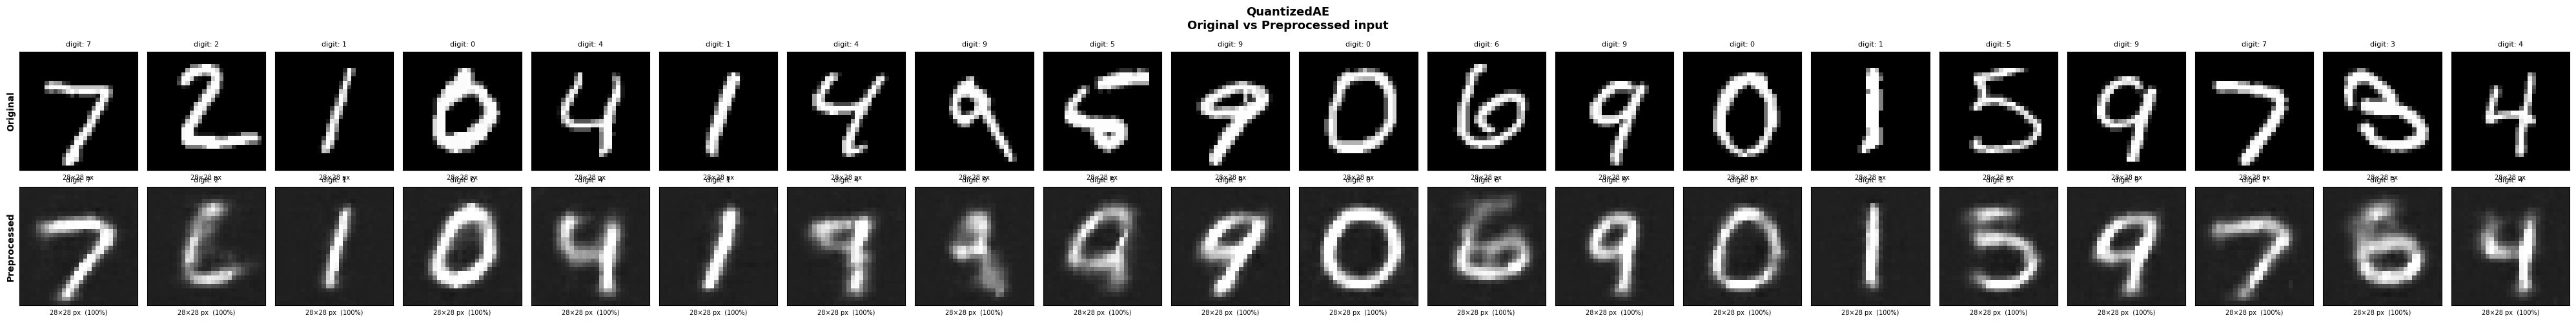

In [10]:
model = load_model(
  QuantizedAE()
)
model_name = type(model).__name__

plot_result_image_table(model, model_name, validate_dl)